# 🌾 HUẤN LUYỆN MÔ HÌNH HỒI QUY TUYẾN TÍNH ƯỚC LƯỢNG SỐ HẠT LÚA (31 FEATURES)
### ĐỀ TÀI NGHIÊN CỨU KHOA HỌC: HỆ THỐNG THỊ GIÁC MÁY TÍNH & HỌC SÂU ĐÁNH GIÁ PHẨM CẤP VÀ ĐẾM HẠT GIỐNG LÚA

---

### 🎯 Mục Tiêu & Điểm Nhấn Của Pipeline Huấn Luyện:
1. **Tận dụng tối đa toàn bộ 31 thuộc tính gốc** được trích xuất từ dữ liệu thực tế và AI (Vật chứa, Bề mặt, Kích thước 2D/3D: Mean, Min, Max, Std).
2. **Huấn luyện và so sánh chéo 6 biến thể Hồi quy Tuyến tính chuẩn mực**:
   - Ordinary Least Squares (OLS) Linear Regression
   - Ridge Regression (L2 Regularization)
   - Lasso Regression (L1 Regularization)
   - ElasticNet Regression (L1 + L2)
   - Huber Regressor (Kháng ngoại lai Robust)
   - Bayesian Ridge Regression (Hồi quy Bayes)
3. **Kiểm tra chéo 5-Fold Cross Validation** trên toàn bộ dữ liệu đảm bảo không bị quá khớp (Overfitting).
4. **Trực quan hóa Đỉnh cao**: Parity Plot ($Actual$ vs $Predicted$), Residuals Analysis, Biểu đồ thanh ngang 31 trọng số $\beta_i$.
5. **Xuất Phương Trình Toán Học & Model Artifacts**: Tự động lưu mô hình `.joblib`, `scaler.joblib`, và tệp JSON chứa phương trình hồi quy tường minh để nhúng vào bất kỳ ứng dụng nào!


In [ ]:
# Bước 1: Kết nối Google Drive & Cài đặt thư viện huấn luyện Machine Learning
from google.colab import drive
import os

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

!pip install pandas numpy scikit-learn matplotlib seaborn joblib openpyxl scipy


Mounted at /content/drive


In [ ]:
# Bước 2: Khai báo Đường dẫn, Nạp Dữ liệu & Chuẩn bị Ma trận X (31 Features) và y (Actual_Count)
import os
import sys
import json
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

# Cài đặt giao diện đồ thị khoa học chuẩn mực
sns.set_theme(style="whitegrid", font_scale=1.02)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# ĐƯỜNG DẪN DỰ ÁN
BASE_PATH = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES"
DATA_CSV_PATH = os.path.join(BASE_PATH, "DATASET_BUILDER/4_Final_Dataset/final_linear_regression_dataset.csv")
DATA_EXCEL_PATH = os.path.join(BASE_PATH, "DATASET_BUILDER/4_Final_Dataset/final_linear_regression_dataset.xlsx")

OUTPUT_MODEL_DIR = os.path.join(BASE_PATH, "LINEAR_REGRESSION_MODEL/models")
OUTPUT_RESULT_DIR = os.path.join(BASE_PATH, "LINEAR_REGRESSION_MODEL/results")
os.makedirs(OUTPUT_MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_RESULT_DIR, exist_ok=True)

if os.path.exists(DATA_CSV_PATH):
    df_raw = pd.read_csv(DATA_CSV_PATH)
elif os.path.exists(DATA_EXCEL_PATH):
    df_raw = pd.read_excel(DATA_EXCEL_PATH)
else:
    df_raw = pd.read_csv("DATASET_BUILDER/4_Final_Dataset/final_linear_regression_dataset.csv")

# Lọc lấy các mẫu hợp lệ đã trích xuất AI (Image_Status == 'FOUND')
df = df_raw[df_raw['Image_Status'] == 'FOUND'].copy()

# Danh sách toàn bộ 31 thuộc tính gốc
ALL_31_FEATURES = [
    # Nhóm 1: Vật chứa & Thể tích khối lúa (8 biến)
    'Bulk_Rice_Volume_mm3', 'Rice_Height_mm', 'Weight_g', 'Empty_Height_mm',
    'Pixels_Per_mm', 'Container_Detected_Diam_px', 'Inner_Diameter_mm', 'Container_Height_mm',
    # Nhóm 2: Bề mặt & Ước lượng (3 biến)
    'Whole_Grains_Count', 'Uniformity_Rate_Pct', 'Estimated_Total_Seeds_Hybrid',
    # Nhóm 3: Chiều dài hạt 2a (4 biến)
    'Grain_Length_mm_Mean', 'Grain_Length_mm_Min', 'Grain_Length_mm_Max', 'Grain_Length_mm_Std',
    # Nhóm 4: Chiều rộng hạt 2b (4 biến)
    'Grain_Width_mm_Mean', 'Grain_Width_mm_Min', 'Grain_Width_mm_Max', 'Grain_Width_mm_Std',
    # Nhóm 5: Chiều dày hạt 2c (4 biến)
    'Grain_Thickness_mm_Mean', 'Grain_Thickness_mm_Min', 'Grain_Thickness_mm_Max', 'Grain_Thickness_mm_Std',
    # Nhóm 6: Diện tích 2D (4 biến)
    'Grain_Area_mm2_Mean', 'Grain_Area_mm2_Min', 'Grain_Area_mm2_Max', 'Grain_Area_mm2_Std',
    # Nhóm 7: Thể tích 3D Hạt (4 biến)
    'Grain_Volume_mm3_Mean', 'Grain_Volume_mm3_Min', 'Grain_Volume_mm3_Max', 'Grain_Volume_mm3_Std'
]

TARGET_COL = 'Actual_Count'

# Chuyển đổi kiểu số
for col in ALL_31_FEATURES + [TARGET_COL]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df.dropna(subset=ALL_31_FEATURES + [TARGET_COL])

X = df_clean[ALL_31_FEATURES].values
y = df_clean[TARGET_COL].values
sample_ids = df_clean['Sample_ID'].values

print("=" * 95)
print("📊 TỔNG QUAN TẬP DỮ LIỆU ĐƯA VÀO HUẤN LUYỆN:")
print("=" * 95)
print(f"🔹 Tổng số mẫu hợp lệ : {len(df_clean)} mẫu")
print(f"🔹 Số chiều đặc trưng : {X.shape[1]} thuộc tính gốc")
print(f"🔹 Biến mục tiêu (Y)  : '{TARGET_COL}' (Số hạt lúa thực tế)")
print(f"🔹 Dải giá trị Y      : Từ {y.min():.0f} đến {y.max():.0f} hạt (Mean={y.mean():.1f}, Median={np.median(y):.1f})")
print("=" * 95)


📊 TỔNG QUAN TẬP DỮ LIỆU ĐƯA VÀO HUẤN LUYỆN:
🔹 Tổng số mẫu hợp lệ : 254 mẫu
🔹 Số chiều đặc trưng : 31 thuộc tính gốc
🔹 Biến mục tiêu (Y)  : 'Actual_Count' (Số hạt lúa thực tế)
🔹 Dải giá trị Y      : Từ 25 đến 305 hạt (Mean=163.1, Median=157.5)


In [ ]:
# Bước 3: Phân Chia Tập Train (80%) / Test (20%) & Chuẩn Hóa StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test, sids_train, sids_test = train_test_split(
    X, y, sample_ids, test_size=0.20, random_state=42, shuffle=True
)

# Chuẩn hóa Z-Score trên tập Train (fit) và biến đổi cho cả Train và Test (transform)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lưu scaler model
scaler_joblib_path = os.path.join(OUTPUT_MODEL_DIR, "scaler.joblib")
joblib.dump(scaler, scaler_joblib_path)

# Lưu tham số scaler dạng JSON
scaler_json_path = os.path.join(OUTPUT_MODEL_DIR, "scaler_params.json")
with open(scaler_json_path, "w", encoding="utf-8") as f:
    json.dump({
        "features": ALL_31_FEATURES,
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist()
    }, f, ensure_ascii=False, indent=2)

print("=" * 95)
print(f"🔹 Tập Huấn Luyện (Train Set): {len(X_train)} mẫu (80.0%)")
print(f"🔹 Tập Kiểm Thử  (Test Set) : {len(X_test)} mẫu (20.0%)")
print(f"💾 Đã lưu StandardScaler vào : {scaler_joblib_path}")
print("=" * 95)


🔹 Tập Huấn Luyện (Train Set): 203 mẫu (80.0%)
🔹 Tập Kiểm Thử  (Test Set) : 51 mẫu (20.0%)
💾 Đã lưu StandardScaler vào : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/LINEAR_REGRESSION_MODEL/models/scaler.joblib


In [1]:
# Bước 4: HUẤN LUYỆN & SO SÁNH CHÉO 6 BIẾN THỂ HỒI QUY TUYẾN TÍNH (5-FOLD CROSS VALIDATION)
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, BayesianRidge
)
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Định nghĩa 6 mô hình hồi quy tuyến tính ứng viên
models_dict = {
    "1. Ridge Regression (L2 - alpha=0.1)": Ridge(alpha=0.1, random_state=42),
    "2. Ordinary Least Squares (OLS)": LinearRegression(),
    "3. Ridge Regularized (L2 - alpha=1.0)": Ridge(alpha=1.0, random_state=42),
    "4. Bayesian Ridge Regression": BayesianRidge(),
    "5. Huber Regressor (Kháng ngoại lai)": HuberRegressor(max_iter=1000),
    "6. ElasticNet (L1 + L2 Combo)": ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
leaderboard_records = []
fitted_models = {}
model_test_preds = {}

N_features = X_train.shape[1]

for model_name, model in models_dict.items():
    # 1. 5-Fold Cross Validation trên tập Train
    cv_r2 = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2')
    cv_mae = -cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')

    # 2. Huấn luyện trên toàn bộ tập Train
    model.fit(X_train_scaled, y_train)
    fitted_models[model_name] = model

    # 3. Dự đoán trên tập Train và Test
    y_tr_pred = model.predict(X_train_scaled)
    y_te_pred = model.predict(X_test_scaled)
    model_test_preds[model_name] = y_te_pred

    # 4. Tính toán các chỉ số đánh giá
    r2_tr = r2_score(y_train, y_tr_pred)
    r2_te = r2_score(y_test, y_te_pred)

    n_te = len(y_test)
    adj_r2_te = 1.0 - ((1.0 - r2_te) * (n_te - 1) / (n_te - N_features - 1)) if (n_te - N_features - 1) > 0 else r2_te

    mae_te = mean_absolute_error(y_test, y_te_pred)
    rmse_te = np.sqrt(mean_squared_error(y_test, y_te_pred))
    mape_te = np.mean(np.abs((y_test - y_te_pred) / y_test)) * 100
    max_err_te = np.max(np.abs(y_test - y_te_pred))

    leaderboard_records.append({
        'Mô_Hình_Hồi_Quy': model_name,
        'R2_Train': round(r2_tr, 4),
        'R2_CV_5Fold': round(np.mean(cv_r2), 4),
        'R2_Test': round(r2_te, 4),
        'Adj_R2_Test': round(adj_r2_te, 4),
        'MAE_Test (hạt)': round(mae_te, 2),
        'RMSE_Test (hạt)': round(rmse_te, 2),
        'MAPE_Test (%)': round(mape_te, 2),
        'Max_Error (hạt)': round(max_err_te, 2)
    })

df_leaderboard = pd.DataFrame(leaderboard_records).sort_values(by='R2_Test', ascending=False).reset_index(drop=True)
df_leaderboard.index = df_leaderboard.index + 1

print("=" * 110)
print("🏆 BẢNG TỔNG KẾT SO SÁNH HIỆU NĂNG 6 THUẬT TOÁN HỒI QUY TUYẾN TÍNH (TOÀN BỘ 31 FEATURES):")
print("=" * 110)
display(df_leaderboard)

# Xuất bảng so sánh ra CSV và Excel
report_csv_path = os.path.join(OUTPUT_RESULT_DIR, "training_evaluation_report.csv")
df_leaderboard.to_csv(report_csv_path, index=False, encoding="utf-8-sig")
print(f"💾 Đã lưu bảng so sánh mô hình vào: {report_csv_path}")


NameError: name 'X_train' is not defined

In [ ]:
# Bước 5: CHỌN MÔ HÌNH TỐI ƯU NHẤT & TRÍCH XUẤT PHƯƠNG TRÌNH TOÁN HỌC HOÀN CHỈNH
best_model_name = df_leaderboard.iloc[0]['Mô_Hình_Hồi_Quy']
best_model = fitted_models[best_model_name]

# Trọng số chuẩn hóa (Standardized Weights)
scaled_coefs = best_model.coef_
scaled_intercept = best_model.intercept_

# Chuyển đổi về không gian biến gốc thực tế (Unscaled Original Equation)
# y = sum(w_scaled_i * (x_i - mean_i) / scale_i) + intercept
# y = sum((w_scaled_i / scale_i) * x_i) + (intercept - sum(w_scaled_i * mean_i / scale_i))
unscaled_coefs = scaled_coefs / scaler.scale_
unscaled_intercept = scaled_intercept - np.sum(scaled_coefs * scaler.mean_ / scaler.scale_)

# Tạo từ điển lưu cấu hình và phương trình
equation_dict = {
    "model_name": best_model_name,
    "target_variable": TARGET_COL,
    "number_of_features": len(ALL_31_FEATURES),
    "r2_score_test": float(df_leaderboard.iloc[0]['R2_Test']),
    "mae_test": float(df_leaderboard.iloc[0]['MAE_Test (hạt)']),
    "mape_test": float(df_leaderboard.iloc[0]['MAPE_Test (%)']),
    "intercept": float(unscaled_intercept),
    "features": []
}

print("=" * 100)
print(f"🌟 MÔ HÌNH TỐT NHẤT ĐƯỢC CHỌN: {best_model_name}")
print("=" * 100)
print(f"📐 PHƯƠNG TRÌNH HỒI QUY TOÁN HỌC HOÀN CHỈNH:")
print(f"Số_Hạt_Dự_Đoán (Actual_Count) = {unscaled_intercept:+.4f}")

for i, feat in enumerate(ALL_31_FEATURES):
    w_sc = float(scaled_coefs[i])
    w_un = float(unscaled_coefs[i])
    equation_dict["features"].append({
        "name": feat,
        "standardized_weight": w_sc,
        "unscaled_coefficient": w_un,
        "mean": float(scaler.mean_[i]),
        "scale": float(scaler.scale_[i])
    })
    sign = "+" if w_un >= 0 else "-"
    print(f"   {sign} ({abs(w_un):.6f} * {feat})")
print("=" * 100 + "\n")

# Lưu file mô hình
best_joblib_path = os.path.join(OUTPUT_MODEL_DIR, "best_linear_regression_model.joblib")
joblib.dump(best_model, best_joblib_path)

eq_json_path = os.path.join(OUTPUT_MODEL_DIR, "regression_equation.json")
with open(eq_json_path, "w", encoding="utf-8") as f:
    json.dump(equation_dict, f, ensure_ascii=False, indent=2)

print(f"💾 Đã lưu trọng số mô hình vào : {best_joblib_path}")
print(f"💾 Đã lưu phương trình JSON vào: {eq_json_path}")


🌟 MÔ HÌNH TỐT NHẤT ĐƯỢC CHỌN: 2. Ordinary Least Squares (OLS)
📐 PHƯƠNG TRÌNH HỒI QUY TOÁN HỌC HOÀN CHỈNH:
Số_Hạt_Dự_Đoán (Actual_Count) = -120.0383
   + (0.000946 * Bulk_Rice_Volume_mm3)
   - (0.385822 * Rice_Height_mm)
   + (39.623341 * Weight_g)
   + (0.558398 * Empty_Height_mm)
   + (1.154821 * Pixels_Per_mm)
   - (0.049199 * Container_Detected_Diam_px)
   + (1.260691 * Inner_Diameter_mm)
   + (1.969830 * Container_Height_mm)
   + (0.084054 * Whole_Grains_Count)
   - (0.025704 * Uniformity_Rate_Pct)
   + (0.000253 * Estimated_Total_Seeds_Hybrid)
   - (114.532516 * Grain_Length_mm_Mean)
   + (1171.311754 * Grain_Length_mm_Min)
   + (469.454452 * Grain_Length_mm_Max)
   + (189.208442 * Grain_Length_mm_Std)
   - (2.324422 * Grain_Width_mm_Mean)
   + (2.556832 * Grain_Width_mm_Min)
   + (0.092893 * Grain_Width_mm_Max)
   + (3.041219 * Grain_Width_mm_Std)
   + (135.508867 * Grain_Thickness_mm_Mean)
   - (1377.377111 * Grain_Thickness_mm_Min)
   - (553.454952 * Grain_Thickness_mm_Max)
   

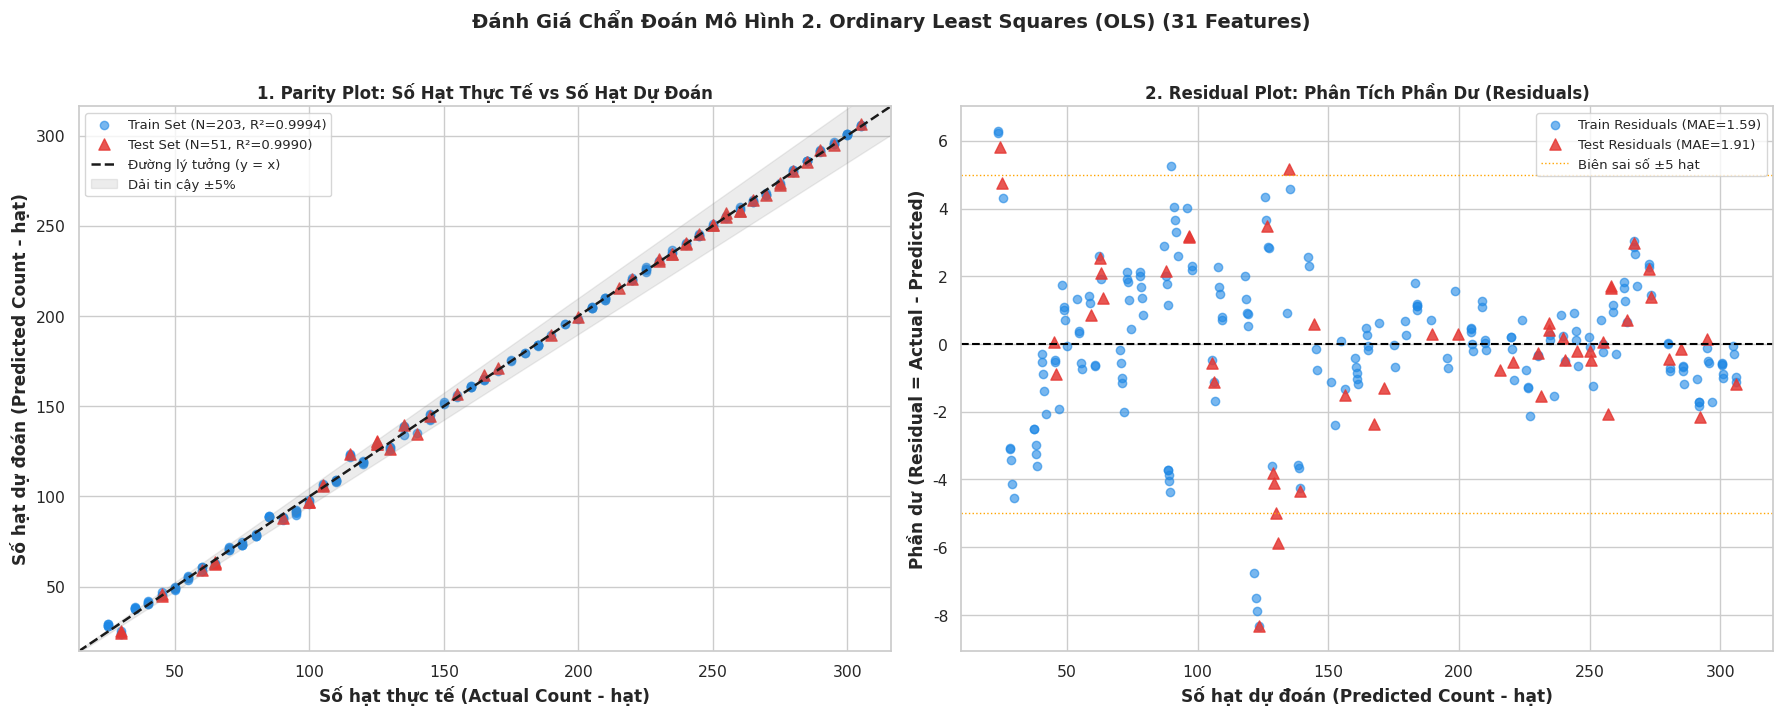

💾 Đã lưu biểu đồ Parity & Residual vào: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/LINEAR_REGRESSION_MODEL/results/1_model_diagnostic_parity_residual_plots.png


In [ ]:
# Bước 6: TRỰC QUAN HÓA ĐÁNH GIÁ MÔ HÌNH (PARITY PLOT & RESIDUALS ANALYSIS)
y_tr_pred = best_model.predict(X_train_scaled)
y_te_pred = best_model.predict(X_test_scaled)

residuals_train = y_train - y_tr_pred
residuals_test = y_test - y_te_pred

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Parity Plot: Actual vs Predicted
min_val = min(y.min(), y_te_pred.min()) - 10
max_val = max(y.max(), y_te_pred.max()) + 10

axes[0].scatter(y_train, y_tr_pred, color='#1E88E5', alpha=0.6, label=f'Train Set (N={len(y_train)}, R²={r2_score(y_train, y_tr_pred):.4f})')
axes[0].scatter(y_test, y_te_pred, color='#E53935', alpha=0.85, marker='^', s=65, label=f'Test Set (N={len(y_test)}, R²={r2_score(y_test, y_te_pred):.4f})')
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.8, label='Đường lý tưởng (y = x)')
axes[0].fill_between([min_val, max_val], [min_val*0.95, max_val*0.95], [min_val*1.05, max_val*1.05], color='gray', alpha=0.15, label='Dải tin cậy ±5%')
axes[0].set_title("1. Parity Plot: Số Hạt Thực Tế vs Số Hạt Dự Đoán", fontweight='bold', fontsize=12)
axes[0].set_xlabel("Số hạt thực tế (Actual Count - hạt)", fontweight='bold')
axes[0].set_ylabel("Số hạt dự đoán (Predicted Count - hạt)", fontweight='bold')
axes[0].set_xlim(min_val, max_val)
axes[0].set_ylim(min_val, max_val)
axes[0].legend(loc='upper left', fontsize=9.5)

# 2. Residual Plot: Phần dư vs Giá trị dự đoán
axes[1].scatter(y_tr_pred, residuals_train, color='#1E88E5', alpha=0.6, label=f'Train Residuals (MAE={mean_absolute_error(y_train, y_tr_pred):.2f})')
axes[1].scatter(y_te_pred, residuals_test, color='#E53935', alpha=0.85, marker='^', s=65, label=f'Test Residuals (MAE={mean_absolute_error(y_test, y_te_pred):.2f})')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].axhline(5, color='orange', linewidth=1, linestyle=':')
axes[1].axhline(-5, color='orange', linewidth=1, linestyle=':', label='Biên sai số ±5 hạt')
axes[1].set_title("2. Residual Plot: Phân Tích Phần Dư (Residuals)", fontweight='bold', fontsize=12)
axes[1].set_xlabel("Số hạt dự đoán (Predicted Count - hạt)", fontweight='bold')
axes[1].set_ylabel("Phần dư (Residual = Actual - Predicted)", fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9.5)

plt.suptitle(f"Đánh Giá Chẩn Đoán Mô Hình {best_model_name} (31 Features)", fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
diag_path = os.path.join(OUTPUT_RESULT_DIR, "1_model_diagnostic_parity_residual_plots.png")
plt.savefig(diag_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Đã lưu biểu đồ Parity & Residual vào: {diag_path}")


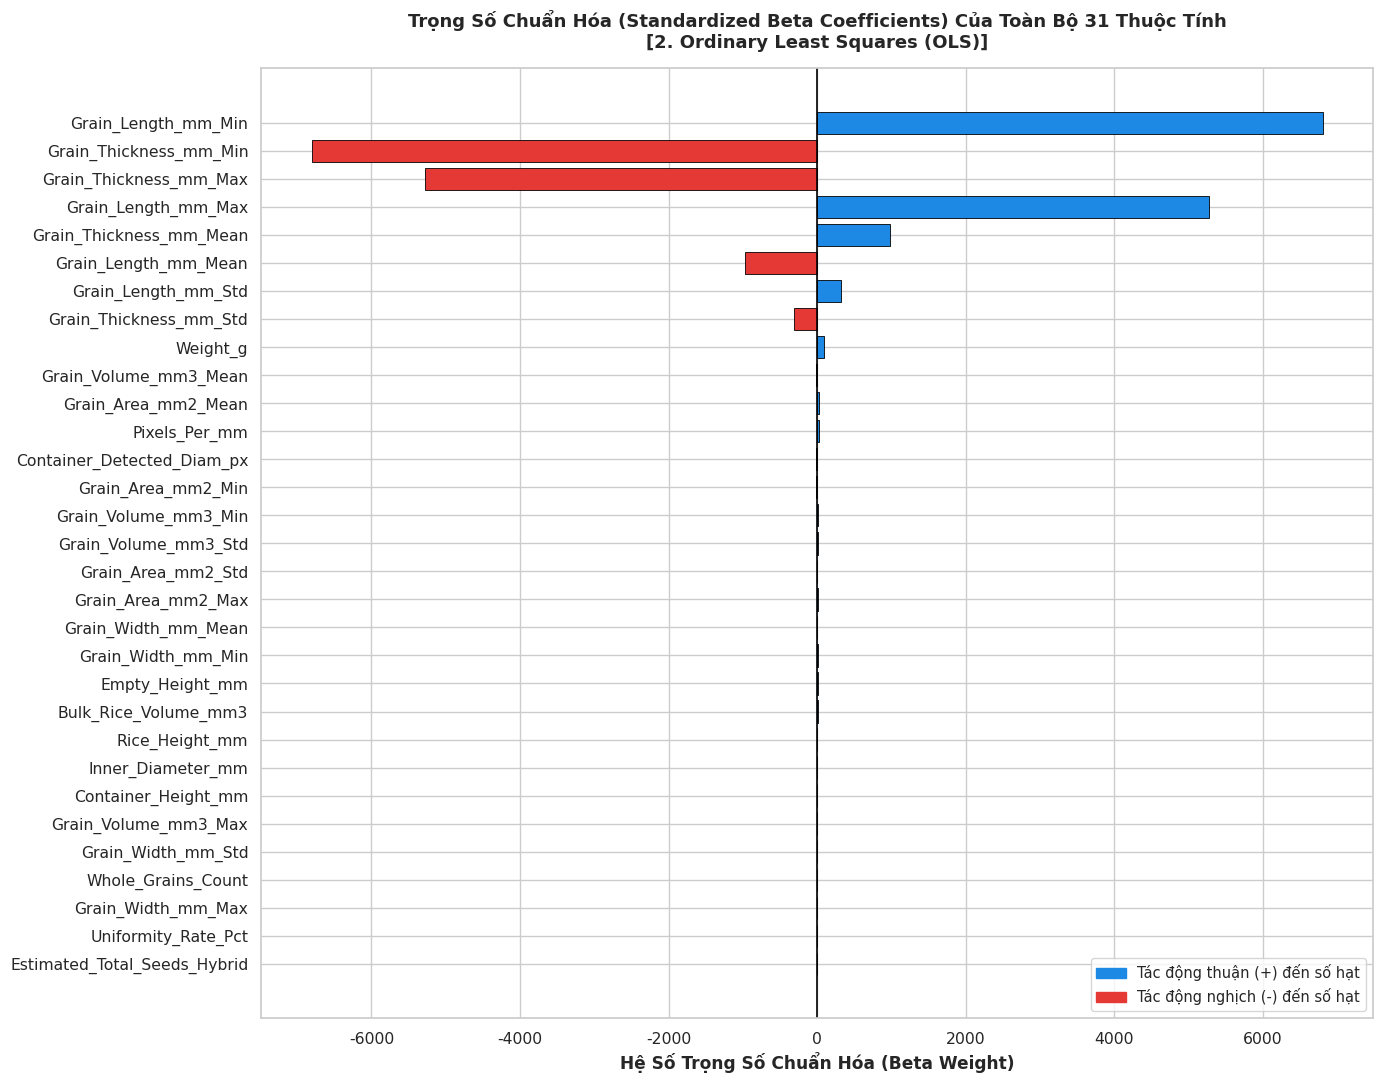

💾 Đã lưu biểu đồ trọng số 31 thuộc tính vào: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/LINEAR_REGRESSION_MODEL/results/2_all_31_features_weights_chart.png


In [ ]:
# Bước 7: TRỰC QUAN HÓA TOÀN BỘ 31 TRỌNG SỐ HỆ SỐ HỒI QUY (FEATURE WEIGHTS)
sorted_idx = np.argsort(np.abs(scaled_coefs))[::-1]
feat_sorted = [ALL_31_FEATURES[i] for i in sorted_idx]
weights_sorted = scaled_coefs[sorted_idx]
colors = ['#1E88E5' if w >= 0 else '#E53935' for w in weights_sorted]

plt.figure(figsize=(14, 11))
bars = plt.barh(feat_sorted[::-1], weights_sorted[::-1], color=colors[::-1], edgecolor='black', linewidth=0.6)
plt.axvline(0, color='black', linewidth=1.2)
plt.title(f"Trọng Số Chuẩn Hóa (Standardized Beta Coefficients) Của Toàn Bộ 31 Thuộc Tính\n[{best_model_name}]", fontweight='bold', fontsize=13, pad=15)
plt.xlabel("Hệ Số Trọng Số Chuẩn Hóa (Beta Weight)", fontweight='bold')

# Chú thích màu sắc
patch_pos = plt.Rectangle((0,0),1,1, color='#1E88E5', label='Tác động thuận (+) đến số hạt')
patch_neg = plt.Rectangle((0,0),1,1, color='#E53935', label='Tác động nghịch (-) đến số hạt')
plt.legend(handles=[patch_pos, patch_neg], loc='lower right', fontsize=10.5)

plt.tight_layout()
weights_chart_path = os.path.join(OUTPUT_RESULT_DIR, "2_all_31_features_weights_chart.png")
plt.savefig(weights_chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Đã lưu biểu đồ trọng số 31 thuộc tính vào: {weights_chart_path}")


In [ ]:
# Bước 8: XUẤT BẢNG KẾT QUẢ DỰ ĐOÁN CHI TIẾT TẬP KIỂM THỬ (TEST SET)
df_test_results = pd.DataFrame({
    'Sample_ID': sids_test,
    'Actual_Count': y_test,
    'Predicted_Count': np.round(y_te_pred, 2),
    'Error_Seeds': np.round(y_te_pred - y_test, 2),
    'Abs_Error': np.round(np.abs(y_te_pred - y_test), 2),
    'Percentage_Error_%': np.round(np.abs((y_te_pred - y_test) / y_test) * 100, 2)
}).sort_values(by='Abs_Error', ascending=False)

test_pred_csv = os.path.join(OUTPUT_RESULT_DIR, "test_set_predictions.csv")
df_test_results.to_csv(test_pred_csv, index=False, encoding="utf-8-sig")

print("=" * 95)
print(f"📋 [BẢNG 10 MẪU TEST DỰ ĐOÁN MẪU]:")
print("=" * 95)
display(df_test_results.head(10))
print(f"💾 Đã lưu toàn bộ bảng dự đoán tập Test vào: {test_pred_csv}")


📋 [BẢNG 10 MẪU TEST DỰ ĐOÁN MẪU]:


,Sample_ID,Actual_Count,Predicted_Count,Error_Seeds,Abs_Error,Percentage_Error_%
28,M003a,115,123.32,8.32,8.32,7.23
17,M004a,125,130.89,5.89,5.89,4.71
24,M007d,30,24.19,-5.81,5.81,19.38
22,M025a,140,134.85,-5.15,5.15,3.68
21,M004e,125,129.99,4.99,4.99,3.99
9,M007a,30,25.24,-4.76,4.76,15.86
19,M005e,135,139.35,4.35,4.35,3.22
37,M004d,125,129.11,4.11,4.11,3.29
46,M004b,125,128.80,3.80,3.80,3.04
4,M024c,130,126.53,-3.47,3.47,2.67


💾 Đã lưu toàn bộ bảng dự đoán tập Test vào: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/LINEAR_REGRESSION_MODEL/results/test_set_predictions.csv


In [ ]:
# Bước 9: THỬ NGHIỆM DỰ ĐOÁN TỨC THÌ CHO 1 MẪU MỚI (INTERACTIVE PREDICTION)
# Bạn có thể thay đổi bất kỳ giá trị nào dưới đây để kiểm tra kết quả dự đoán số hạt:
sample_test_input = {
    "Bulk_Rice_Volume_mm3": 5723.45,
    "Rice_Height_mm": 23.0,
    "Weight_g": 2.69,
    "Empty_Height_mm": 10.9,
    "Pixels_Per_mm": 37.15,
    "Container_Detected_Diam_px": 661.0,
    "Inner_Diameter_mm": 17.8,
    "Container_Height_mm": 33.9,
    "Whole_Grains_Count": 7.0,
    "Uniformity_Rate_Pct": 100.0,
    "Estimated_Total_Seeds_Hybrid": 141.0,
    "Grain_Length_mm_Mean": 5.33,
    "Grain_Length_mm_Min": 3.74,
    "Grain_Length_mm_Max": 6.87,
    "Grain_Length_mm_Std": 0.98,
    "Grain_Width_mm_Mean": 1.86,
    "Grain_Width_mm_Min": 1.56,
    "Grain_Width_mm_Max": 2.35,
    "Grain_Width_mm_Std": 0.29,
    "Grain_Thickness_mm_Mean": 4.53,
    "Grain_Thickness_mm_Min": 3.18,
    "Grain_Thickness_mm_Max": 5.84,
    "Grain_Thickness_mm_Std": 0.84,
    "Grain_Area_mm2_Mean": 7.38,
    "Grain_Area_mm2_Min": 5.38,
    "Grain_Area_mm2_Max": 11.40,
    "Grain_Area_mm2_Std": 2.29,
    "Grain_Volume_mm3_Mean": 25.19,
    "Grain_Volume_mm3_Min": 11.96,
    "Grain_Volume_mm3_Max": 49.25,
    "Grain_Volume_mm3_Std": 12.73
}

# Chuyển sample thành vector mảng
sample_vector = np.array([[sample_test_input[feat] for feat in ALL_31_FEATURES]])
sample_vector_scaled = scaler.transform(sample_vector)
predicted_count = best_model.predict(sample_vector_scaled)[0]

print("=" * 80)
print("🎯 KẾT QUẢ DỰ ĐOÁN SỐ LƯỢNG HẠT CHO MẪU:")
print("=" * 80)
print(f"🔹 Số hạt dự đoán (Predicted Count) : {int(round(predicted_count))} HẠT (Giá trị thô: {predicted_count:.2f})")
print(f"🔹 Độ tin cậy mô hình             : R² = {df_leaderboard.iloc[0]['R2_Test']} (Sai số MAE ~{df_leaderboard.iloc[0]['MAE_Test (hạt)']} hạt)")
print("=" * 80)


🎯 KẾT QUẢ DỰ ĐOÁN SỐ LƯỢNG HẠT CHO MẪU:
🔹 Số hạt dự đoán (Predicted Count) : 86 HẠT (Giá trị thô: 85.69)
🔹 Độ tin cậy mô hình             : R² = 0.999 (Sai số MAE ~1.91 hạt)
